## Bangladesh Displacement Risk Visualization

This notebook visualizes displacement risk results for Bangladesh at the admin1 level,
showing coastal flood, riverine flood, and their combined impact.

In [1]:
# load libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, BoundaryNorm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

In [2]:
# paths
results_path = '../results/'
shp_path = '../data/shapefiles/gadm41_BGD_shp/'
fig_save_path = '../results/'

In [3]:
# Load admin1 shapefile
admin1 = gpd.read_file(f'{shp_path}gadm41_BGD_1.shp')
print(f"Shapefile columns: {admin1.columns.tolist()}")
print(f"Number of admin1 regions: {len(admin1)}")
admin1.head()

Shapefile columns: ['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
Number of admin1 regions: 8


,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,BGD.1_1,BGD,Bangladesh,Barisal,Bakerganj,NA,Bibhag,Division,10,BD.BA,NA,"MULTIPOLYGON (((90.77085 21.85966, 90.771 21.8..."
1,BGD.2_1,BGD,Bangladesh,Chittagong,Chattagram|Parbattya Chattagram|,NA,Bibhag,Division,20,BD.CG,NA,"MULTIPOLYGON (((92.33417 20.79306, 92.33417 20..."
2,BGD.3_1,BGD,Bangladesh,Dhaka,Daca|Dacca,NA,Bibhag,Division,30,BD.DH,BD-C,"MULTIPOLYGON (((90.23322 23.01469, 90.23289 23..."
3,BGD.4_1,BGD,Bangladesh,Khulna,NA,NA,Bibhag,Division,40,BD.KH,BD-D,"MULTIPOLYGON (((89.28793 21.77268, 89.28807 21..."
4,BGD.8_1,BGD,Bangladesh,Mymensingh,NA,NA,Bibhag,Division,NA,BD.MM,NA,"POLYGON ((90.49482 24.31438, 90.49467 24.31431..."


In [4]:
# Load displacement data (using medium vulnerability scenario)
coastal_df = pd.read_csv(f'{results_path}BGD_displacement_coastal_admin1_high.csv')
riverine_df = pd.read_csv(f'{results_path}BGD_displacement_riverine_admin1_high.csv')

print("Coastal data:")
print(coastal_df)
print("\nRiverine data:")
print(riverine_df)

Coastal data:
  admin1_name           RP_2           RP_5         RP_10         RP_25  \
0     BGD.1_1  103076.477083  231506.163569  3.897982e+05  8.708548e+05   
1     BGD.2_1   18858.652577   85159.808450  2.869371e+05  5.746211e+05   
2     BGD.3_1   75566.797593  154298.825063  2.547123e+05  3.929206e+05   
3     BGD.4_1  284042.237271  874226.095486  1.078317e+06  1.437926e+06   
4     BGD.8_1       0.000000       0.000000  0.000000e+00  0.000000e+00   
5     BGD.5_1       0.000000       0.000000  0.000000e+00  0.000000e+00   
6     BGD.6_1       0.000000       0.000000  0.000000e+00  0.000000e+00   
7     BGD.7_1       0.000000       0.000000  0.000000e+00  6.630366e+01   

          RP_50        RP_100        RP_250        RP_500       RP_1000  \
0  1.433290e+06  1.969824e+06  2.620885e+06  3.038491e+06  3.437726e+06   
1  8.714525e+05  1.230287e+06  1.778447e+06  2.170712e+06  2.610481e+06   
2  8.112771e+05  1.127387e+06  1.610728e+06  2.499259e+06  3.268513e+06   
3  1.67863

In [5]:
# Merge data with shapefile
# The admin1_name in CSV corresponds to GID_1 in shapefile
coastal_merged = admin1.merge(coastal_df, left_on='GID_1', right_on='admin1_name', how='left')
riverine_merged = admin1.merge(riverine_df, left_on='GID_1', right_on='admin1_name', how='left')

# Compute sum of coastal and riverine
combined_df = coastal_df.copy()
combined_df['AED'] = coastal_df['AED'].fillna(0) + riverine_df['AED'].fillna(0)
combined_merged = admin1.merge(combined_df, left_on='GID_1', right_on='admin1_name', how='left')

In [6]:
def plot_bgd_admin1_tripanel(coastal_gdf, riverine_gdf, combined_gdf, metric='AED', save=True):
    """
    Plot a 3-panel side-by-side map of Bangladesh admin1 displacement results.
    
    Args:
        coastal_gdf: GeoDataFrame with coastal flood data
        riverine_gdf: GeoDataFrame with riverine flood data  
        combined_gdf: GeoDataFrame with combined (sum) data
        metric: Column name to plot (default: 'AED')
        save: Whether to save the figure
    """
    
    # Update font sizes for publication-ready figure
    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 10,
        'axes.labelsize': 10,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8
    })
    
    # Create figure with 3 panels
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))
    
    # Get global min/max across all datasets for consistent color scale
    all_values = pd.concat([
        coastal_gdf[metric].dropna(),
        riverine_gdf[metric].dropna(),
        combined_gdf[metric].dropna()
    ])
    all_values = all_values[all_values > 0]  # Only positive values for log scale
    
    if len(all_values) == 0:
        print("No positive values found in data")
        return
    
    combined_min = max(1, all_values.min())
    combined_max = all_values.max()
    
    # Continuous log-scale colormap
    cmap = 'cividis'
    norm = LogNorm(vmin=combined_min, vmax=combined_max)
    
    # Panel data and titles
    panels = [
        (coastal_gdf, 'Coastal Flood'),
        (riverine_gdf, 'Riverine Flood'),
        (combined_gdf, 'Combined')
    ]
    
    for i, (gdf, title) in enumerate(panels):
        ax = axes[i]
        
        # Categorize data
        gdf = gdf.copy()
        gdf['metric_category'] = gdf[metric].apply(
            lambda x: 'zero' if x == 0 else ('value' if pd.notna(x) and x > 0 else 'missing')
        )
        
        # Plot regions with positive values
        value_gdf = gdf[gdf['metric_category'] == 'value']
        if len(value_gdf) > 0:
            value_gdf.plot(
                column=metric,
                ax=ax,
                cmap=cmap,
                norm=norm,
                edgecolor='black',
                linewidth=0.5
            )
        
        # Plot zero values in gray
        zero_gdf = gdf[gdf['metric_category'] == 'zero']
        if len(zero_gdf) > 0:
            zero_gdf.plot(
                color='#d6d6d6',
                ax=ax,
                edgecolor='black',
                linewidth=0.5
            )
        
        # Plot missing values in white
        missing_gdf = gdf[gdf['metric_category'] == 'missing']
        if len(missing_gdf) > 0:
            missing_gdf.plot(
                color='#ffffff',
                ax=ax,
                edgecolor='black',
                linewidth=0.5
            )
        
        ax.set_title(title, fontsize=12)
        ax.set_axis_off()
    
    # Add shared colorbar below panels
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    
    # Set ticks at powers of 10
    min_log = int(np.floor(np.log10(combined_min)))
    max_log = int(np.ceil(np.log10(combined_max)))
    ticks = [10**i for i in range(min_log, max_log + 1)]
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', ticks=ticks)
    
    def format_number(n):
        if n >= 1e6: return f'{n/1e6:.0f}M' if n % 1e6 == 0 else f'{n/1e6:.1f}M'
        elif n >= 1e3: return f'{n/1e3:.0f}K' if n % 1e3 == 0 else f'{n/1e3:.1f}K'
        else: return f'{n:.0f}'
    cbar.set_ticklabels([format_number(t) for t in ticks])
    cbar.set_label('Annual Expected Displacement (AED)', fontsize=10)
    
    # Add legend for zero values
    legend_elements = [Patch(facecolor='#d6d6d6', edgecolor='black', label='Zero displacement')]
    fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.95, 0.05))
    
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    
    if save:
        save_fig_str = f'BGD_admin1_displacement_tripanel_{metric}.png'
        plt.savefig(
            fig_save_path + save_fig_str,
            dpi=300,
            facecolor='w',
            edgecolor='w',
            format='png',
            bbox_inches='tight',
            pad_inches=0.1
        )
        print(f"Figure saved to {fig_save_path + save_fig_str}")
    
    plt.show()

Figure saved to ../results/BGD_admin1_displacement_tripanel_AED.png


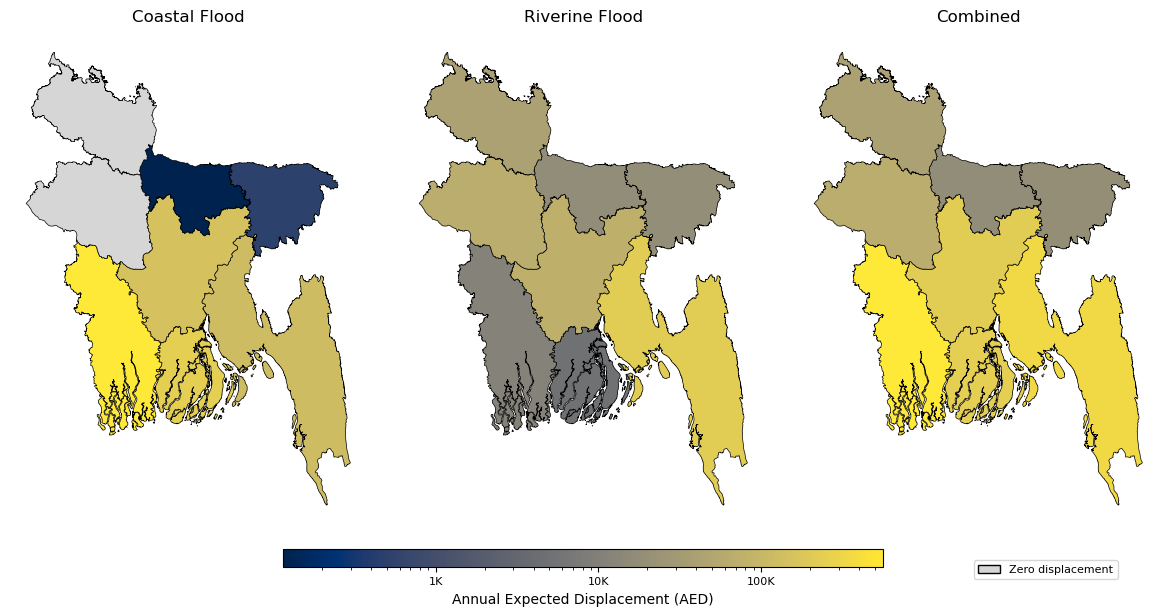

In [7]:
# Generate the 3-panel plot
plot_bgd_admin1_tripanel(coastal_merged, riverine_merged, combined_merged, metric='AED', save=True)

In [8]:
# Load all threshold files and compute combined (coastal + riverine) for each
# High threshold
coastal_high = pd.read_csv(f'{results_path}BGD_displacement_coastal_admin1_high.csv')
riverine_high = pd.read_csv(f'{results_path}BGD_displacement_riverine_admin1_high.csv')
combined_high = coastal_high.copy()
combined_high['AED'] = coastal_high['AED'].fillna(0) + riverine_high['AED'].fillna(0)
combined_high_merged = admin1.merge(combined_high, left_on='GID_1', right_on='admin1_name', how='left')

# Medium threshold
coastal_med = pd.read_csv(f'{results_path}BGD_displacement_coastal_admin1_med.csv')
riverine_med = pd.read_csv(f'{results_path}BGD_displacement_riverine_admin1_med.csv')
combined_med = coastal_med.copy()
combined_med['AED'] = coastal_med['AED'].fillna(0) + riverine_med['AED'].fillna(0)
combined_med_merged = admin1.merge(combined_med, left_on='GID_1', right_on='admin1_name', how='left')

# Low threshold
coastal_low = pd.read_csv(f'{results_path}BGD_displacement_coastal_admin1_low.csv')
riverine_low = pd.read_csv(f'{results_path}BGD_displacement_riverine_admin1_low.csv')
combined_low = coastal_low.copy()
combined_low['AED'] = coastal_low['AED'].fillna(0) + riverine_low['AED'].fillna(0)
combined_low_merged = admin1.merge(combined_low, left_on='GID_1', right_on='admin1_name', how='left')

print("Data loaded for all thresholds")

Data loaded for all thresholds


Figure saved to ../results/BGD_admin1_displacement_thresholds_AED.png


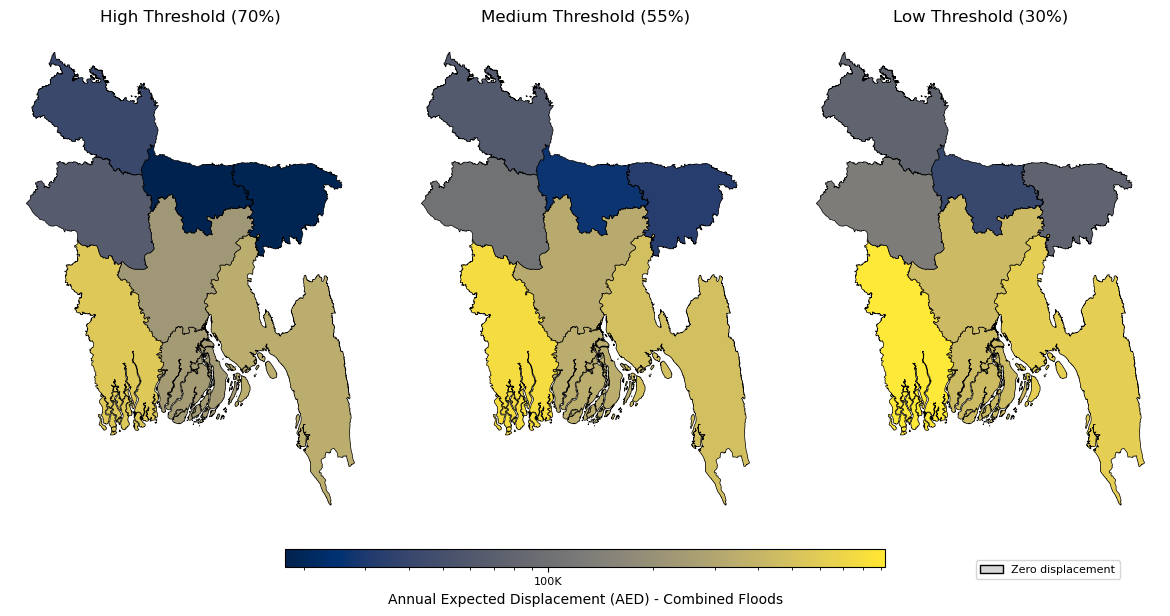

In [9]:
# Plot 3-panel figure comparing thresholds (High, Med, Low)
def plot_bgd_thresholds_tripanel(high_gdf, med_gdf, low_gdf, metric='AED', save=True):
    """
    Plot a 3-panel side-by-side map comparing displacement thresholds.
    """
    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 10,
        'axes.labelsize': 10,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8
    })
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))
    
    # Get global min/max across all datasets
    all_values = pd.concat([
        high_gdf[metric].dropna(),
        med_gdf[metric].dropna(),
        low_gdf[metric].dropna()
    ])
    all_values = all_values[all_values > 0]
    
    if len(all_values) == 0:
        print("No positive values found")
        return
    
    combined_min = max(1, all_values.min())
    combined_max = all_values.max()
    
    # Continuous log-scale colormap
    cmap = 'cividis'
    norm = LogNorm(vmin=combined_min, vmax=combined_max)
    
    # Panels: High, Med, Low
    panels = [
        (high_gdf, 'High Threshold (70%)'),
        (med_gdf, 'Medium Threshold (55%)'),
        (low_gdf, 'Low Threshold (30%)')
    ]
    
    for i, (gdf, title) in enumerate(panels):
        ax = axes[i]
        gdf = gdf.copy()
        gdf['metric_category'] = gdf[metric].apply(
            lambda x: 'zero' if x == 0 else ('value' if pd.notna(x) and x > 0 else 'missing')
        )
        
        value_gdf = gdf[gdf['metric_category'] == 'value']
        if len(value_gdf) > 0:
            value_gdf.plot(column=metric, ax=ax, cmap=cmap, norm=norm, edgecolor='black', linewidth=0.5)
        
        zero_gdf = gdf[gdf['metric_category'] == 'zero']
        if len(zero_gdf) > 0:
            zero_gdf.plot(color='#d6d6d6', ax=ax, edgecolor='black', linewidth=0.5)
        
        missing_gdf = gdf[gdf['metric_category'] == 'missing']
        if len(missing_gdf) > 0:
            missing_gdf.plot(color='#ffffff', ax=ax, edgecolor='black', linewidth=0.5)
        
        ax.set_title(title, fontsize=12)
        ax.set_axis_off()
    
    # Colorbar
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    
    # Set ticks at powers of 10
    min_log = int(np.floor(np.log10(combined_min)))
    max_log = int(np.ceil(np.log10(combined_max)))
    ticks = [10**i for i in range(min_log, max_log + 1)]
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', ticks=ticks)
    
    def format_number(n):
        if n >= 1e6: return f'{n/1e6:.0f}M' if n % 1e6 == 0 else f'{n/1e6:.1f}M'
        elif n >= 1e3: return f'{n/1e3:.0f}K' if n % 1e3 == 0 else f'{n/1e3:.1f}K'
        else: return f'{n:.0f}'
    cbar.set_ticklabels([format_number(t) for t in ticks])
    cbar.set_label('Annual Expected Displacement (AED) - Combined Floods', fontsize=10)
    
    legend_elements = [Patch(facecolor='#d6d6d6', edgecolor='black', label='Zero displacement')]
    fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.95, 0.05))
    
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    
    if save:
        save_fig_str = f'BGD_admin1_displacement_thresholds_{metric}.png'
        plt.savefig(fig_save_path + save_fig_str, dpi=300, facecolor='w', edgecolor='w', format='png', bbox_inches='tight', pad_inches=0.1)
        print(f"Figure saved to {fig_save_path + save_fig_str}")
    
    plt.show()

# Generate the thresholds comparison plot
plot_bgd_thresholds_tripanel(combined_high_merged, combined_med_merged, combined_low_merged, metric='AED', save=True)

## Admin2 Displacement Maps

Visualize displacement risk results at the admin2 (district) level.

In [10]:
# Load admin2 shapefile
admin2 = gpd.read_file(f'{shp_path}gadm41_BGD_2.shp')
print(f"Admin2 shapefile: {len(admin2)} regions")
print(f"Columns: {admin2.columns.tolist()}")

# Load admin2 displacement data (high threshold) and merge
coastal_admin2_df = pd.read_csv(f'{results_path}BGD_displacement_coastal_admin2_high.csv')
riverine_admin2_df = pd.read_csv(f'{results_path}BGD_displacement_riverine_admin2_high.csv')

coastal_admin2_merged = admin2.merge(coastal_admin2_df, left_on='NAME_2', right_on='admin2_name', how='left')
riverine_admin2_merged = admin2.merge(riverine_admin2_df, left_on='NAME_2', right_on='admin2_name', how='left')

combined_admin2_df = coastal_admin2_df.copy()
combined_admin2_df['AED'] = coastal_admin2_df['AED'].fillna(0) + riverine_admin2_df['AED'].fillna(0)
combined_admin2_merged = admin2.merge(combined_admin2_df, left_on='NAME_2', right_on='admin2_name', how='left')

print(f"Merged coastal: {coastal_admin2_merged['AED'].notna().sum()}/{len(admin2)} regions matched")
print(f"Merged riverine: {riverine_admin2_merged['AED'].notna().sum()}/{len(admin2)} regions matched")

Admin2 shapefile: 64 regions
Columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']
Merged coastal: 64/64 regions matched
Merged riverine: 64/64 regions matched


Figure saved to ../results/BGD_admin2_displacement_tripanel_AED.png


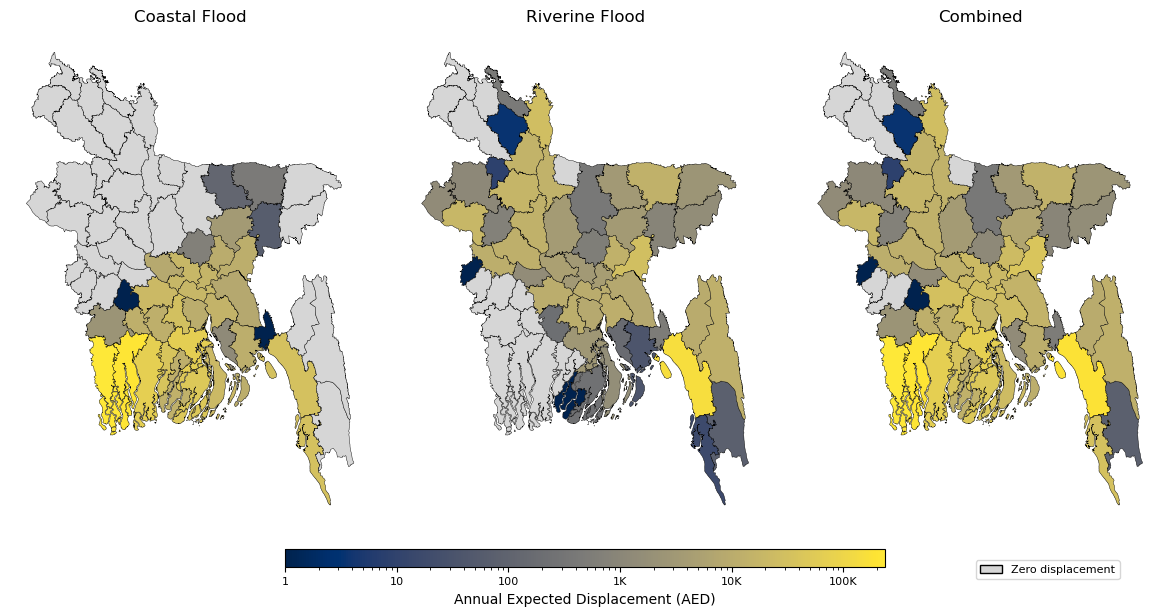

In [17]:
def plot_bgd_admin2_tripanel(coastal_gdf, riverine_gdf, combined_gdf, metric='AED', save=True):
    """
    Plot a 3-panel side-by-side map of Bangladesh admin2 displacement results.
    """
    plt.rcParams.update({
        'font.size': 10, 'axes.titlesize': 10, 'axes.labelsize': 10,
        'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8
    })
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))
    
    all_values = pd.concat([
        coastal_gdf[metric].dropna(),
        riverine_gdf[metric].dropna(),
        combined_gdf[metric].dropna()
    ])
    all_values = all_values[all_values > 0]
    
    if len(all_values) == 0:
        print("No positive values found in data")
        return
    
    combined_min = max(1, all_values.min())
    combined_max = all_values.max()
    
    # Continuous log-scale colormap
    cmap = 'cividis'
    norm = LogNorm(vmin=combined_min, vmax=combined_max)
    
    panels = [
        (coastal_gdf, 'Coastal Flood'),
        (riverine_gdf, 'Riverine Flood'),
        (combined_gdf, 'Combined')
    ]
    
    for i, (gdf, title) in enumerate(panels):
        ax = axes[i]
        gdf = gdf.copy()
        gdf['metric_category'] = gdf[metric].apply(
            lambda x: 'zero' if x == 0 else ('value' if pd.notna(x) and x > 0 else 'missing')
        )
        
        value_gdf = gdf[gdf['metric_category'] == 'value']
        if len(value_gdf) > 0:
            value_gdf.plot(column=metric, ax=ax, cmap=cmap, norm=norm, edgecolor='black', linewidth=0.3)
        
        zero_gdf = gdf[gdf['metric_category'] == 'zero']
        if len(zero_gdf) > 0:
            zero_gdf.plot(color='#d6d6d6', ax=ax, edgecolor='black', linewidth=0.3)
        
        missing_gdf = gdf[gdf['metric_category'] == 'missing']
        if len(missing_gdf) > 0:
            missing_gdf.plot(color='#ffffff', ax=ax, edgecolor='black', linewidth=0.3)
        
        ax.set_title(title, fontsize=12)
        ax.set_axis_off()
    
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    
    # Set ticks at powers of 10
    min_log = int(np.floor(np.log10(combined_min)))
    max_log = int(np.ceil(np.log10(combined_max)))
    ticks = [10**i for i in range(min_log, max_log + 1)]
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', ticks=ticks)
    
    def format_number(n):
        if n >= 1e6: return f'{n/1e6:.0f}M' if n % 1e6 == 0 else f'{n/1e6:.1f}M'
        elif n >= 1e3: return f'{n/1e3:.0f}K' if n % 1e3 == 0 else f'{n/1e3:.1f}K'
        else: return f'{n:.0f}'
    cbar.set_ticklabels([format_number(t) for t in ticks])
    cbar.set_label('Annual Expected Displacement (AED)', fontsize=10)
    
    legend_elements = [Patch(facecolor='#d6d6d6', edgecolor='black', label='Zero displacement')]
    fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.95, 0.05))
    
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    
    if save:
        save_fig_str = f'BGD_admin2_displacement_tripanel_{metric}.png'
        plt.savefig(fig_save_path + save_fig_str, dpi=300, facecolor='w', edgecolor='w',
                    format='png', bbox_inches='tight', pad_inches=0.1)
        print(f"Figure saved to {fig_save_path + save_fig_str}")
    
    plt.show()

# Generate the admin2 3-panel plot (coastal / riverine / combined)
plot_bgd_admin2_tripanel(coastal_admin2_merged, riverine_admin2_merged, combined_admin2_merged, metric='AED', save=True)

Admin2 data loaded for all thresholds
Figure saved to ../results/BGD_admin2_displacement_thresholds_AED.png


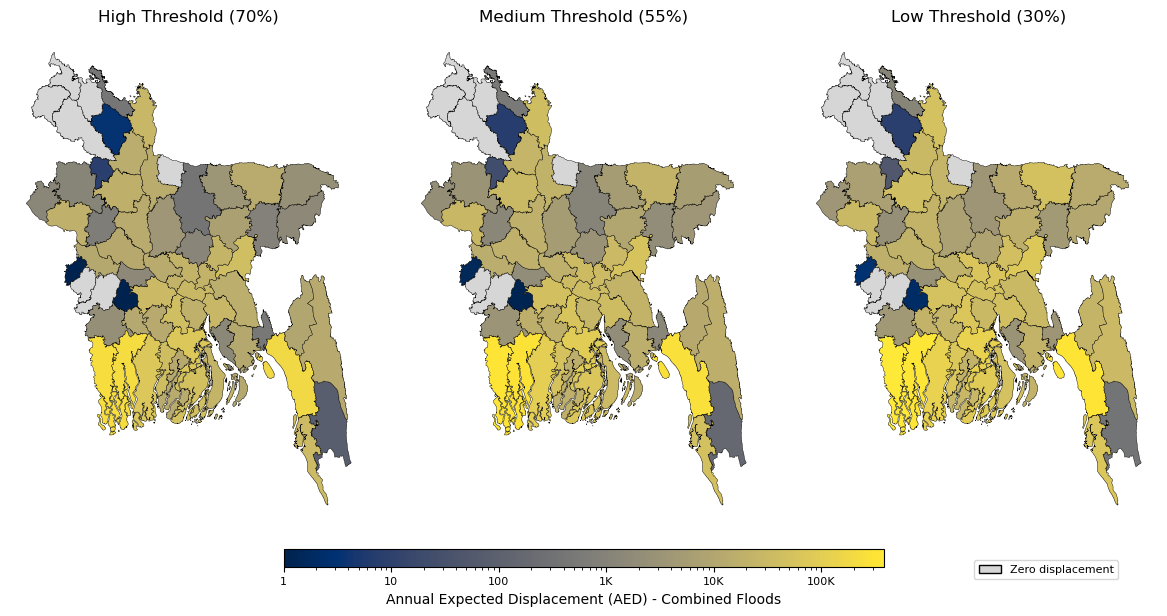

In [12]:
# Load all admin2 threshold files and compute combined for each
# High threshold
coastal_admin2_high = pd.read_csv(f'{results_path}BGD_displacement_coastal_admin2_high.csv')
riverine_admin2_high = pd.read_csv(f'{results_path}BGD_displacement_riverine_admin2_high.csv')
combined_admin2_high = coastal_admin2_high.copy()
combined_admin2_high['AED'] = coastal_admin2_high['AED'].fillna(0) + riverine_admin2_high['AED'].fillna(0)
combined_admin2_high_merged = admin2.merge(combined_admin2_high, left_on='NAME_2', right_on='admin2_name', how='left')

# Medium threshold
coastal_admin2_med = pd.read_csv(f'{results_path}BGD_displacement_coastal_admin2_med.csv')
riverine_admin2_med = pd.read_csv(f'{results_path}BGD_displacement_riverine_admin2_med.csv')
combined_admin2_med = coastal_admin2_med.copy()
combined_admin2_med['AED'] = coastal_admin2_med['AED'].fillna(0) + riverine_admin2_med['AED'].fillna(0)
combined_admin2_med_merged = admin2.merge(combined_admin2_med, left_on='NAME_2', right_on='admin2_name', how='left')

# Low threshold
coastal_admin2_low = pd.read_csv(f'{results_path}BGD_displacement_coastal_admin2_low.csv')
riverine_admin2_low = pd.read_csv(f'{results_path}BGD_displacement_riverine_admin2_low.csv')
combined_admin2_low = coastal_admin2_low.copy()
combined_admin2_low['AED'] = coastal_admin2_low['AED'].fillna(0) + riverine_admin2_low['AED'].fillna(0)
combined_admin2_low_merged = admin2.merge(combined_admin2_low, left_on='NAME_2', right_on='admin2_name', how='left')

print("Admin2 data loaded for all thresholds")

# Plot admin2 thresholds comparison (high / med / low)
def plot_bgd_admin2_thresholds_tripanel(high_gdf, med_gdf, low_gdf, metric='AED', save=True):
    """
    Plot a 3-panel side-by-side map comparing displacement thresholds at admin2 level.
    """
    plt.rcParams.update({
        'font.size': 10, 'axes.titlesize': 10, 'axes.labelsize': 10,
        'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8
    })
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))
    
    all_values = pd.concat([
        high_gdf[metric].dropna(),
        med_gdf[metric].dropna(),
        low_gdf[metric].dropna()
    ])
    all_values = all_values[all_values > 0]
    
    if len(all_values) == 0:
        print("No positive values found")
        return
    
    combined_min = max(1, all_values.min())
    combined_max = all_values.max()
    
    # Continuous log-scale colormap
    cmap = 'cividis'
    norm = LogNorm(vmin=combined_min, vmax=combined_max)
    
    panels = [
        (high_gdf, 'High Threshold (70%)'),
        (med_gdf, 'Medium Threshold (55%)'),
        (low_gdf, 'Low Threshold (30%)')
    ]
    
    for i, (gdf, title) in enumerate(panels):
        ax = axes[i]
        gdf = gdf.copy()
        gdf['metric_category'] = gdf[metric].apply(
            lambda x: 'zero' if x == 0 else ('value' if pd.notna(x) and x > 0 else 'missing')
        )
        
        value_gdf = gdf[gdf['metric_category'] == 'value']
        if len(value_gdf) > 0:
            value_gdf.plot(column=metric, ax=ax, cmap=cmap, norm=norm, edgecolor='black', linewidth=0.3)
        
        zero_gdf = gdf[gdf['metric_category'] == 'zero']
        if len(zero_gdf) > 0:
            zero_gdf.plot(color='#d6d6d6', ax=ax, edgecolor='black', linewidth=0.3)
        
        missing_gdf = gdf[gdf['metric_category'] == 'missing']
        if len(missing_gdf) > 0:
            missing_gdf.plot(color='#ffffff', ax=ax, edgecolor='black', linewidth=0.3)
        
        ax.set_title(title, fontsize=12)
        ax.set_axis_off()
    
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    
    # Set ticks at powers of 10
    min_log = int(np.floor(np.log10(combined_min)))
    max_log = int(np.ceil(np.log10(combined_max)))
    ticks = [10**i for i in range(min_log, max_log + 1)]
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', ticks=ticks)
    
    def format_number(n):
        if n >= 1e6: return f'{n/1e6:.0f}M' if n % 1e6 == 0 else f'{n/1e6:.1f}M'
        elif n >= 1e3: return f'{n/1e3:.0f}K' if n % 1e3 == 0 else f'{n/1e3:.1f}K'
        else: return f'{n:.0f}'
    cbar.set_ticklabels([format_number(t) for t in ticks])
    cbar.set_label('Annual Expected Displacement (AED) - Combined Floods', fontsize=10)
    
    legend_elements = [Patch(facecolor='#d6d6d6', edgecolor='black', label='Zero displacement')]
    fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.95, 0.05))
    
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    
    if save:
        save_fig_str = f'BGD_admin2_displacement_thresholds_{metric}.png'
        plt.savefig(fig_save_path + save_fig_str, dpi=300, facecolor='w', edgecolor='w',
                    format='png', bbox_inches='tight', pad_inches=0.1)
        print(f"Figure saved to {fig_save_path + save_fig_str}")
    
    plt.show()

# Generate the admin2 thresholds comparison plot
plot_bgd_admin2_thresholds_tripanel(combined_admin2_high_merged, combined_admin2_med_merged, combined_admin2_low_merged, metric='AED', save=True)